## IMPORTACIÓN DE LIBRERÍAS Y CARGA DE DATOS

In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import requests
import zipfile
import io


%matplotlib inline
sns.set_theme(style="whitegrid")
pd.set_option('display.max_columns', None)  #

url = "https://archive.ics.uci.edu/static/public/222/bank+marketing.zip"
print("Descargando el dataset desde UCI...")


response = requests.get(url)


with zipfile.ZipFile(io.BytesIO(response.content)) as outer_zip:

    with outer_zip.open('bank-additional.zip') as inner_zip_file:
        with zipfile.ZipFile(io.BytesIO(inner_zip_file.read())) as inner_zip:

            with inner_zip.open('bank-additional/bank-additional-full.csv') as csv_file:
                df = pd.read_csv(csv_file, sep=';')

print(f"¡Dataset cargado con éxito! El dataframe tiene {df.shape[0]} filas y {df.shape[1]} columnas.")

Descargando el dataset desde UCI...
¡Dataset cargado con éxito! El dataframe tiene 41188 filas y 21 columnas.


## Análisis Exploratorio de Datos (EDA)

In [2]:
#Mostrar las primeras 5 filas del dataset
print("--- Primeras 5 filas del Dataset ---")
display(df.head())

#Conocer los tipos de datos por columna y si hay nulos evidentes
print("\n--- Información General del DataFrame ---")
df.info()

#Verificar la distribución de nuestra variable objetivo ('y')
print("\n--- Distribución de la Variable Objetivo (Contrató depósito: yes/no) ---")
print(df['y'].value_counts())
print("\nEn porcentaje:")
print(df['y'].value_counts(normalize=True) * 100)

--- Primeras 5 filas del Dataset ---


,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,261,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,149,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,226,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,151,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,307,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no



--- Información General del DataFrame ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  object 
 2   marital         41188 non-null  object 
 3   education       41188 non-null  object 
 4   default         41188 non-null  object 
 5   housing         41188 non-null  object 
 6   loan            41188 non-null  object 
 7   contact         41188 non-null  object 
 8   month           41188 non-null  object 
 9   day_of_week     41188 non-null  object 
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  object 
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  f

Estadísticas descriptivas de las variables numéricas:


,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41188.00000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000
mean,40.02406,258.285010,2.567593,962.475454,0.172963,0.081886,93.575664,-40.502600,3.621291,5167.035911
std,10.42125,259.279249,2.770014,186.910907,0.494901,1.570960,0.578840,4.628198,1.734447,72.251528
min,17.00000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,32.00000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,38.00000,180.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.00000,319.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,98.00000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


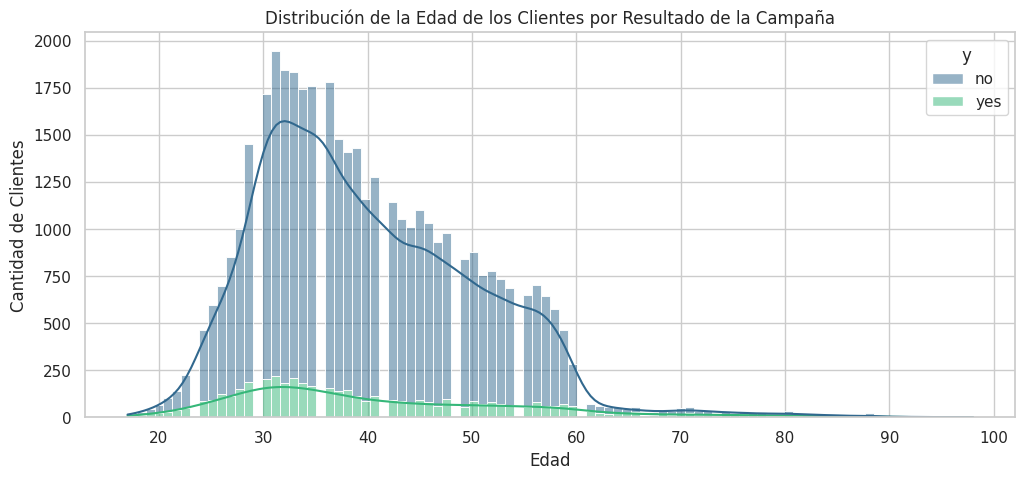

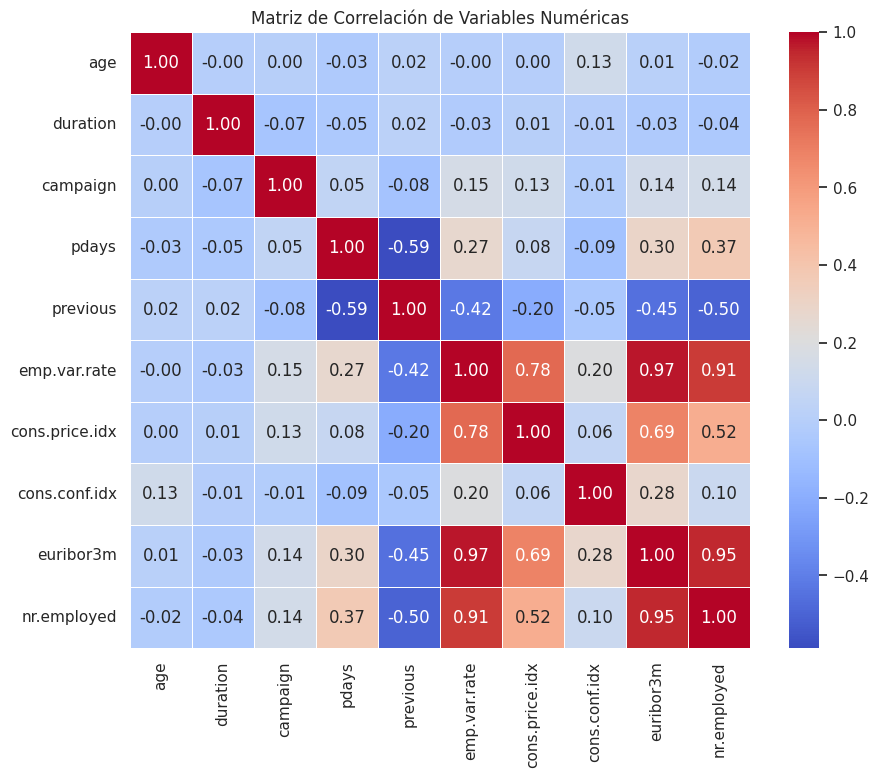

In [3]:
# Estadísticas descriptivas generales para entender rangos, medias y valores atípicos
print("Estadísticas descriptivas de las variables numéricas:")
display(df.describe())

# Visualización de la distribución de la edad según si contrataron o no el depósito
plt.figure(figsize=(12, 5))
sns.histplot(data=df, x='age', hue='y', multiple='stack', kde=True, palette='viridis')
plt.title('Distribución de la Edad de los Clientes por Resultado de la Campaña')
plt.xlabel('Edad')
plt.ylabel('Cantidad de Clientes')
plt.show()

# Matriz de correlación para identificar relaciones lineales entre variables numéricas
plt.figure(figsize=(10, 8))
# Seleccionamos solo las columnas numéricas para calcular la correlación
numeric_cols = df.select_dtypes(include=[np.number]).columns
correlation_matrix = df[numeric_cols].corr()

sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Matriz de Correlación de Variables Numéricas')
plt.show()

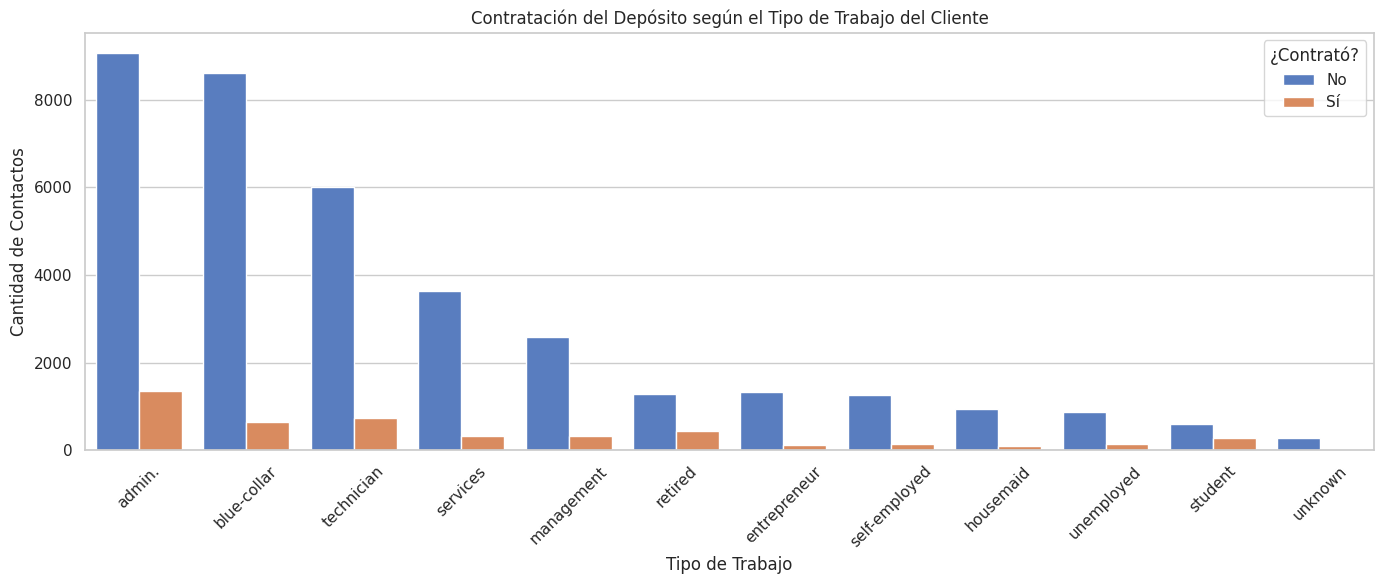

Porcentaje de éxito (conversión) según el estado civil:


y,no,yes
marital,,
divorced,89.679098,10.320902
married,89.842747,10.157253
single,85.995851,14.004149
unknown,85.000000,15.000000


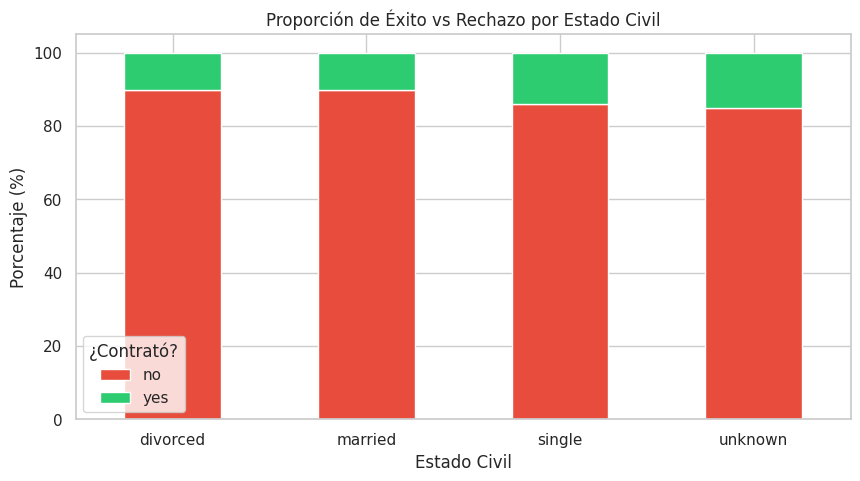

In [5]:
# Análisis del impacto del tipo de trabajo en la contratación del depósito
plt.figure(figsize=(14, 6))
job_order = df['job'].value_counts().index
sns.countplot(data=df, x='job', hue='y', order=job_order, palette='muted')
plt.title('Contratación del Depósito según el Tipo de Trabajo del Cliente')
plt.xlabel('Tipo de Trabajo')
plt.ylabel('Cantidad de Contactos')
plt.xticks(rotation=45)
plt.legend(title='¿Contrató?', labels=['No', 'Sí'])
plt.tight_layout()
plt.show()

# Análisis de la tasa de conversión real (porcentaje de 'yes') por estado civil
marital_conversion = df.groupby('marital')['y'].value_counts(normalize=True).unstack() * 100
print("Porcentaje de éxito (conversión) según el estado civil:")
display(marital_conversion)

# Gráfico de barras apiladas para el estado civil
marital_conversion.plot(kind='bar', stacked=True, figsize=(10, 5), color=['#e74c3c', '#2ecc71'])
plt.title('Proporción de Éxito vs Rechazo por Estado Civil')
plt.xlabel('Estado Civil')
plt.ylabel('Porcentaje (%)')
plt.xticks(rotation=0)
plt.legend(title='¿Contrató?')
plt.show()

## Preparación de Datos (Data Preprocessing)

In [7]:
# Importamos los módulos necesarios de Scikit-Learn para preprocesamiento y partición
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Creamos una copia limpia para no modificar el dataframe original
df_processed = df.copy()

# Tratamiento de la variable 'pdays': Creamos una variable binaria que indique si fue contactado antes o no
# Ya que 999 distorsiona los modelos basados en distancia si se deja como número continuo
df_processed['was_previously_contacted'] = np.where(df_processed['pdays'] == 999, 0, 1)
df_processed = df_processed.drop(columns=['pdays'])

# Convertimos la variable objetivo 'y' (yes/no) en valores numéricos (1/0)
df_processed['y'] = df_processed['y'].map({'yes': 1, 'no': 0})

# Separamos las características (X) de la etiqueta objetivo (y)
X = df_processed.drop(columns=['y'])
y = df_processed['y']

# Aplicamos One-Hot Encoding a todas las variables categóricas (texto)
# drop_first=True evita la trampa de la variable ficticia eliminando columnas redundantes
X = pd.get_dummies(X, drop_first=True)

# Dividimos los datos en conjuntos de Entrenamiento (80%) y Prueba (20%)
# Usamos stratify=y para garantizar que la proporción de 'yes' y 'no' se mantenga igual en ambos grupos
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Escalamos las variables numéricas continuas
# Es indispensable para modelos como Regresión Logística o Redes Neuronales
scaler = StandardScaler()

# Identificamos las variables numéricas originales que quedan en nuestro set
numeric_features = ['age', 'duration', 'campaign', 'previous', 'emp.var.rate',
                    'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']

# Ajustamos el escalador solo con los datos de entrenamiento y transformamos ambos conjuntos
X_train[numeric_features] = scaler.fit_transform(X_train[numeric_features])
X_test[numeric_features] = scaler.transform(X_test[numeric_features])

print("Forma de X_train:", X_train.shape)
print("Forma de X_test:", X_test.shape)
print("\n¡Datos preparados, codificados y escalados con éxito!")

Forma de X_train: (32950, 53)
Forma de X_test: (8238, 53)

¡Datos preparados, codificados y escalados con éxito!


## Data Modeling

In [8]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

In [9]:
# MODELO 1: REGRESIÓN LOGÍSTICA
print("Entrenando Regresión Logística...")
lr_model = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)

# Predicciones
y_pred_lr = lr_model.predict(X_test)

# Reporte de métricas
print("\n--- Reporte de Clasificación - Regresión Logística ---")
print(classification_report(y_test, y_pred_lr))

Entrenando Regresión Logística...

--- Reporte de Clasificación - Regresión Logística ---
              precision    recall  f1-score   support

           0       0.99      0.86      0.92      7310
           1       0.45      0.91      0.60       928

    accuracy                           0.86      8238
   macro avg       0.72      0.89      0.76      8238
weighted avg       0.93      0.86      0.88      8238



In [10]:
# MODELO 2: RANDOM FOREST
print("\nEntrenando Random Forest...")
rf_model = RandomForestClassifier(class_weight='balanced', random_state=42, n_estimators=100)
rf_model.fit(X_train, y_train)

# Predicciones
y_pred_rf = rf_model.predict(X_test)

# Reporte de métricas
print("\n--- Reporte de Clasificación - Random Forest ---")
print(classification_report(y_test, y_pred_rf))


Entrenando Random Forest...

--- Reporte de Clasificación - Random Forest ---
              precision    recall  f1-score   support

           0       0.93      0.98      0.95      7310
           1       0.70      0.44      0.54       928

    accuracy                           0.92      8238
   macro avg       0.81      0.71      0.75      8238
weighted avg       0.91      0.92      0.91      8238



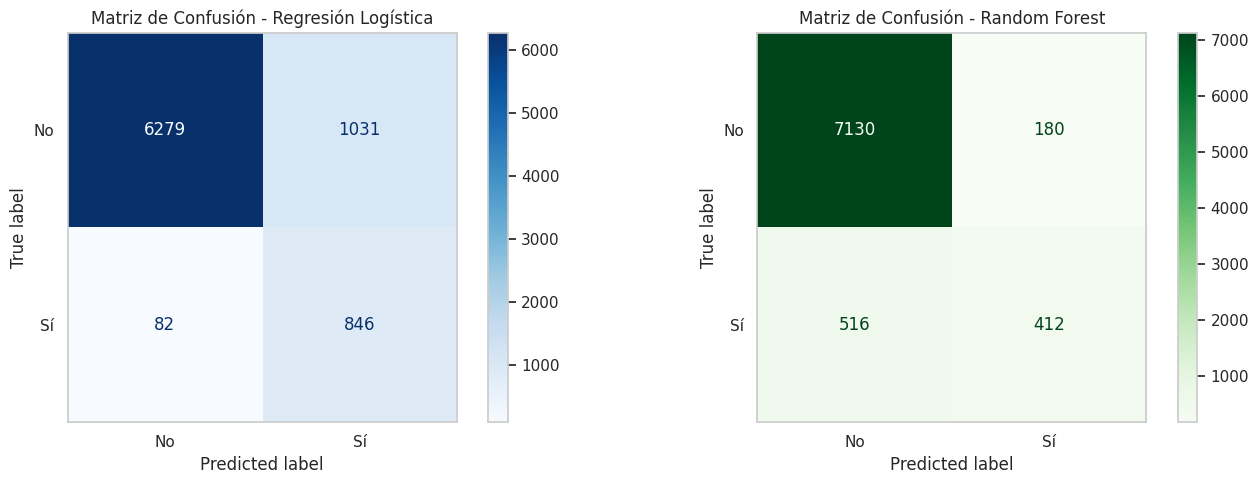

In [11]:
# VISUALIZACIÓN: MATRICES DE CONFUSIÓN

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Matriz Regresión Logística
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_lr, ax=ax[0], cmap='Blues', display_labels=['No', 'Sí']
)
ax[0].set_title('Matriz de Confusión - Regresión Logística')
ax[0].grid(False) # Desactivar líneas de cuadrícula para ver mejor la matriz

# Matriz Random Forest
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_rf, ax=ax[1], cmap='Greens', display_labels=['No', 'Sí']
)
ax[1].set_title('Matriz de Confusión - Random Forest')
ax[1].grid(False)

plt.tight_layout()
plt.show()

/tmp/ipykernel_4944/3209073507.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importances, x='Impacto', y='Variable', palette='coolwarm')


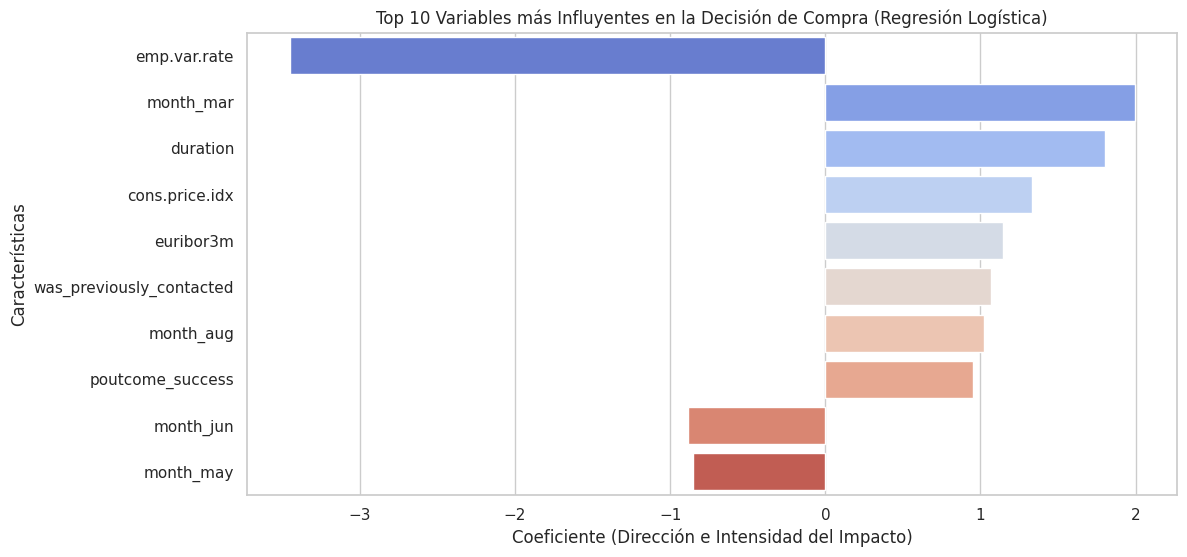

In [12]:
# Extraemos los coeficientes del modelo ganador (Regresión Logística)
# Usamos el valor absoluto para medir la fuerza del impacto, ya sea positivo o negativo
importances = pd.DataFrame({
    'Variable': X_train.columns,
    'Impacto': lr_model.coef_[0]
})

# Ordenamos por la fuerza del impacto absoluto
importances['Impacto_Absoluto'] = importances['Impacto'].abs()
importances = importances.sort_values(by='Impacto_Absoluto', ascending=False).head(10)

# Graficamos el top 10 de variables más influyentes
plt.figure(figsize=(12, 6))
sns.barplot(data=importances, x='Impacto', y='Variable', palette='coolwarm')
plt.title('Top 10 Variables más Influyentes en la Decisión de Compra (Regresión Logística)')
plt.xlabel('Coeficiente (Dirección e Intensidad del Impacto)')
plt.ylabel('Características')
plt.show()